<a href="https://colab.research.google.com/github/NamithaRStat/Casestudy_18_6_2026/blob/main/Casestudy_tensorflow_vs_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
import time

import torch
import torch.nn as nn
import torch.optim as optim

# Reading file

In [35]:
filepath ='/content/drive/MyDrive/ICT_AIML/data/adult_dataset.csv'

In [36]:
adult_df = pd.read_csv(filepath)

# EDA

In [37]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [38]:
for i in adult_df.columns:
  print("columns :",i)
  print("unique",adult_df[i].unique())

  # occupation- have  "?", need to be replaced
  # native-country "?", need to be replaced
 # columns : income--unique ['<=50K' '>50K' '<=50K.' '>50K.']; replace '.' with null

columns : age
unique [ 39.  50.  38.  53.  28.  37.  49.  52.  31.  42.  30.  23.  32.  40.
  34.  25.  nan  54.  35.  43.  59.  56.  19.  20.  45.  22.  48.  21.
  24.  57.  44.  41.  29.  18.  47.  46.  79.  27.  67.  33.  76.  17.
 120.  36.  55.  61.  70.  64.  71.  68.  66.  51.  58.  26.  60.  90.
  75.  65.  77.  62.  63.  80.  74.  72.  69.  73.  81.  88. 250.  78.
  82.  83. 255.  84.  85. 225. 230.  86.  87.  89. 140. 100. 210.]
columns : workclass
unique ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' nan 'Local-gov'
 '?' 'Self-emp-inc' 'Without-pay' 'Never-worked']
columns : fnlwgt
unique [ 77516  83311 215646 ... 173449  89686 350977]
columns : education
unique ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
columns : education-num
unique [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
columns : marital-status
unique ['Never-married' 'Married

In [39]:
# replacements with mode
adult_df['occupation'] = adult_df['occupation'].replace('?', np.nan)
adult_df['occupation'] = adult_df['occupation'].fillna(adult_df['occupation'].mode()[0])

adult_df['native-country'] = adult_df['native-country'].replace('?', np.nan)
adult_df['native-country'] = adult_df['native-country'].fillna(adult_df['native-country'].mode()[0])

adult_df['workclass'] = adult_df['workclass'].replace('?', np.nan)
adult_df['workclass'] = adult_df['workclass'].fillna(adult_df['workclass'].mode()[0])

In [40]:
adult_df['income'] = adult_df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

In [41]:
adult_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


# Preprocessing

In [42]:
adult_df.isna().sum()

,0
age,2442
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [43]:
adult_df['age'] = adult_df['age'].fillna(adult_df['age'].median())

In [44]:
adult_df['hours-per-week'] = adult_df['hours-per-week'].fillna(adult_df['hours-per-week'].median())

In [45]:
num_cols = adult_df.select_dtypes(include = ['int64','float64'])

# selecting non- numeric columns
cat_cols = adult_df.select_dtypes(include = ['object'])

## Outliers

In [46]:
num_cols.shape

(48842, 6)

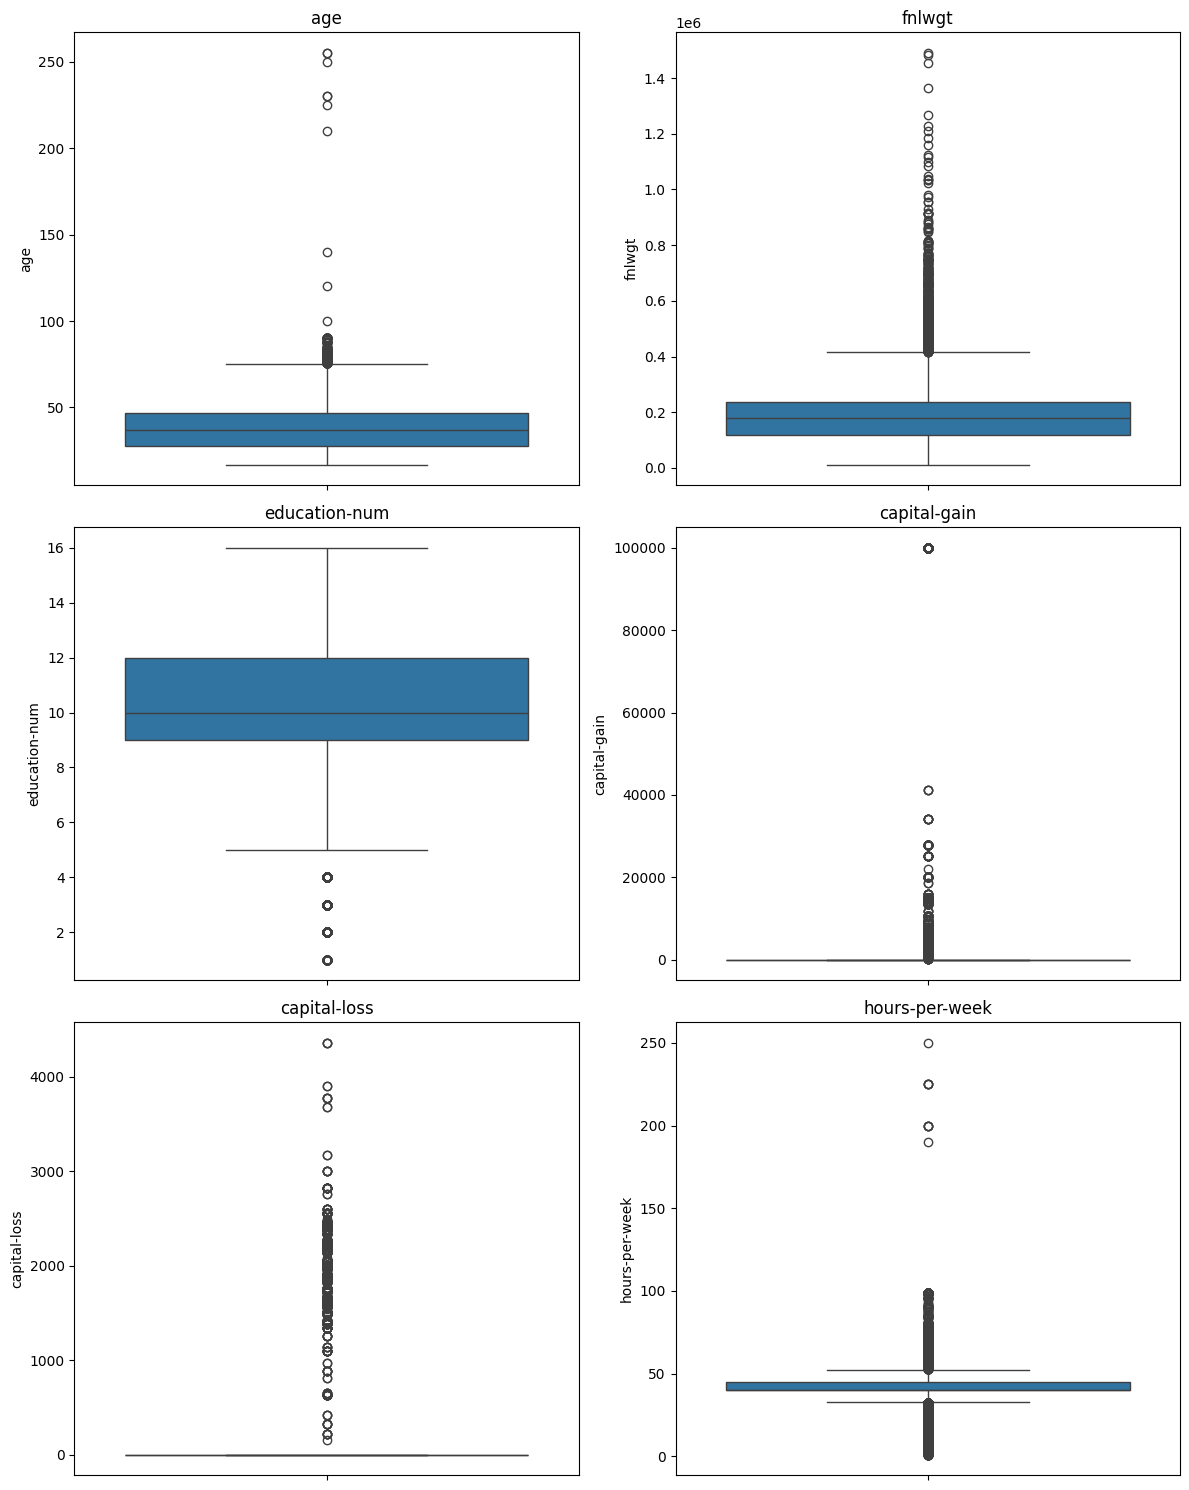

In [14]:
plt.figure(figsize=(12,15))

i= 1 # making first index as 1
for column in num_cols :
  plt.subplot(3,2,i)
  sns.boxplot(num_cols[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [15]:
num_cols.columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [16]:

adult_df = adult_df[adult_df['age']<= 100]
adult_df = adult_df[adult_df['hours-per-week']<= 168]

## duplicates

In [17]:
adult_df.duplicated().sum()

np.int64(44)

In [18]:
adult_df = adult_df.drop_duplicates()

# Checking Assosiations

In [19]:
adult_corr = adult_df.corr(numeric_only= True)
adult_corr

# there small correlations between different numerical columns.

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.075178,0.030292,0.075122,0.056009,0.066790
fnlwgt,-0.075178,1.000000,-0.038676,-0.003705,-0.004386,-0.011271
education-num,0.030292,-0.038676,1.000000,0.125231,0.081063,0.139445
capital-gain,0.075122,-0.003705,0.125231,1.000000,-0.031469,0.081973
capital-loss,0.056009,-0.004386,0.081063,-0.031469,1.000000,0.051083
hours-per-week,0.066790,-0.011271,0.139445,0.081973,0.051083,1.000000


<Axes: >

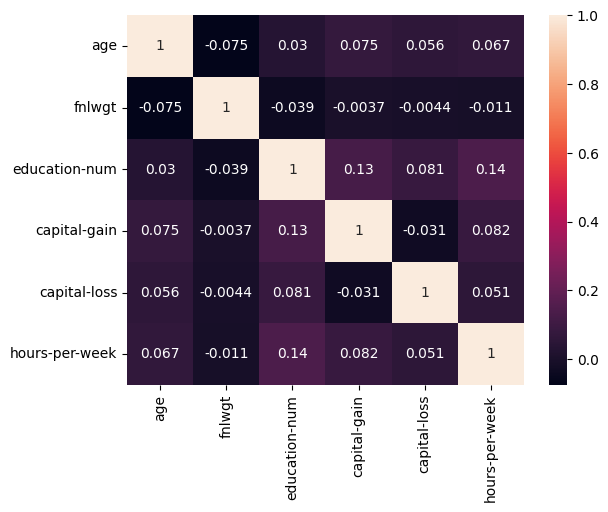

In [20]:
sns.heatmap(adult_corr,annot = True)

# Encoding

In [21]:
# checking unique values in cate- columns
for i in cat_cols.columns:
  print(i)
  print(cat_cols[i].unique())

  ## one hot encoding columns - 'workclass','education','marital-status','occupation','relationship','race','native-country'
  ## label encoding for 'sex' 'income'

workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
race
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
sex
['Male' 'Female']
native-country
['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Germany' 'Iran' 'Phi

In [22]:
adult_df= pd.get_dummies( adult_df,columns = cat_cols.columns,dtype = int)
adult_df

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K,income_>50K
0,39.0,77516,13,2174,0,40.0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,50.0,83311,13,0,0,13.0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,38.0,215646,9,0,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
3,53.0,234721,7,0,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
4,28.0,338409,13,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,215419,13,0,0,36.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
48838,64.0,321403,9,0,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
48839,38.0,374983,13,0,0,50.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
48840,44.0,83891,13,5455,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0


In [23]:
adult_df

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K,income_>50K
0,39.0,77516,13,2174,0,40.0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,50.0,83311,13,0,0,13.0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,38.0,215646,9,0,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
3,53.0,234721,7,0,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
4,28.0,338409,13,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,215419,13,0,0,36.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
48838,64.0,321403,9,0,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
48839,38.0,374983,13,0,0,50.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
48840,44.0,83891,13,5455,0,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0


In [24]:
adult_df.columns
#label_encoder = LabelEncoder()
#adult_df = label_encoder.fit_transform(adult_df[label_df.columns])

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       ...
       'native-country_Scotland', 'native-country_South',
       'native-country_Taiwan', 'native-country_Thailand',
       'native-country_Trinadad&Tobago', 'native-country_United-States',
       'native-country_Vietnam', 'native-country_Yugoslavia', 'income_<=50K',
       'income_>50K'],
      dtype='object', length=107)

In [25]:
# dropping columns'income_>50K' and 'sex_Male'

In [26]:
adult_df = adult_df.drop(['income_>50K', 'sex_Male'], axis=1)

# Splitting

In [27]:
y= adult_df['income_<=50K']
X = adult_df.drop('income_<=50K', axis = 1)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.20,
    random_state= 42
)

# Scaling

In [29]:
num_cols.shape

(48842, 6)

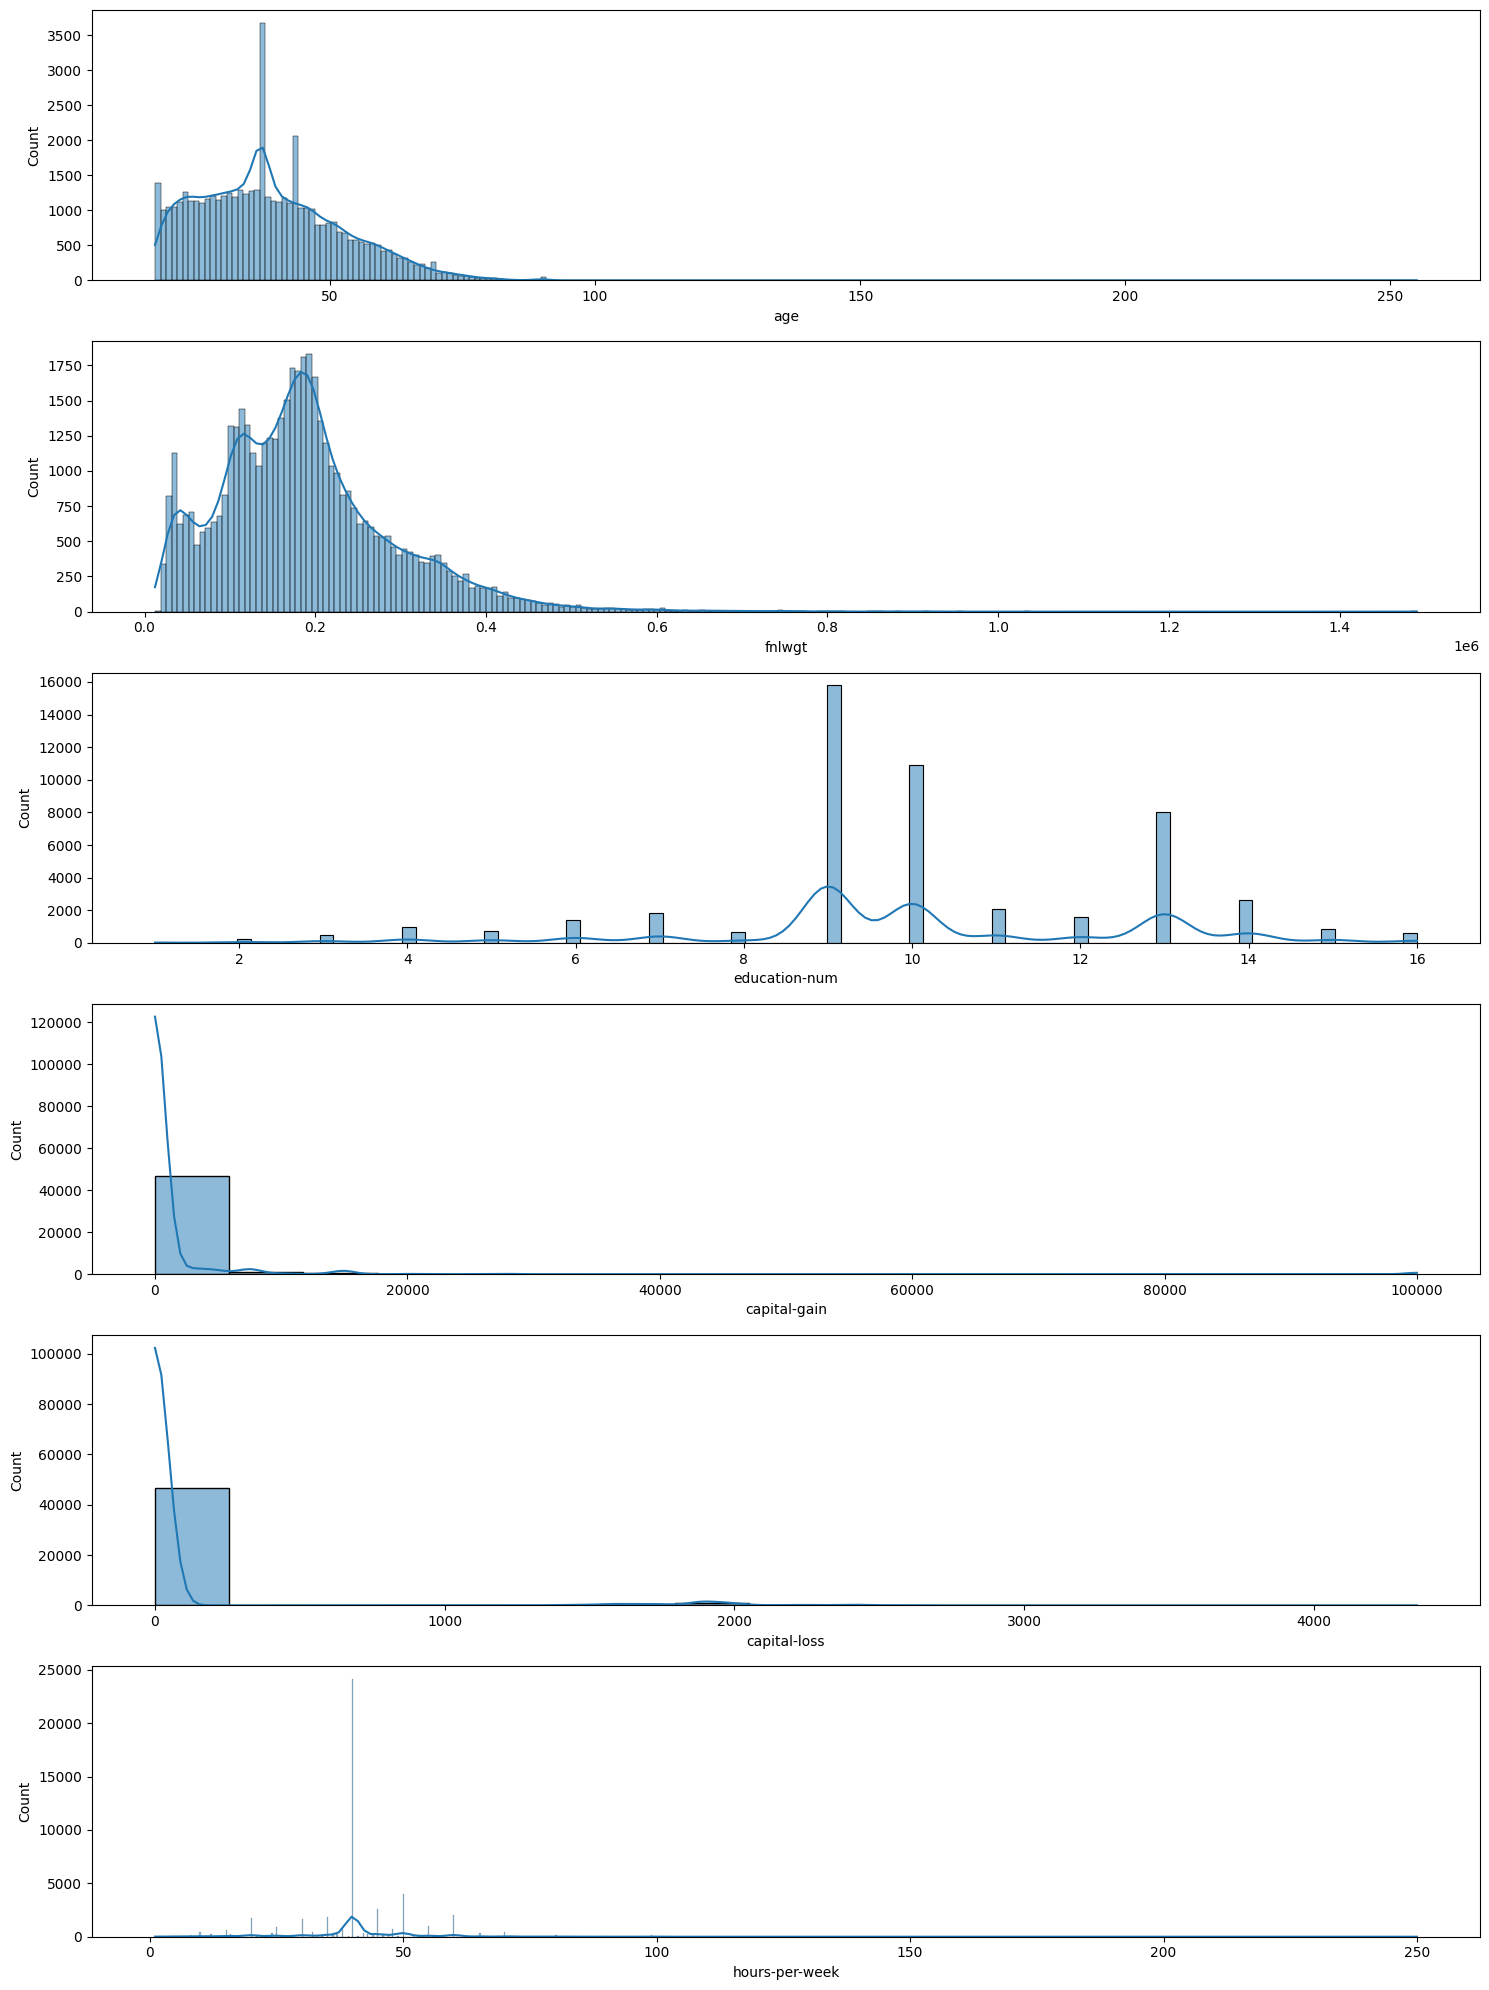

In [30]:
plt.figure(figsize =(15,20))

i= 1
for column in num_cols :
  plt.subplot(6,1,i)
  sns.histplot(num_cols[column], kde = True)
  i += 1

plt.tight_layout()
plt.show()


In [31]:
num_cols.columns


Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [32]:
print(X_train.columns)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       ...
       'native-country_Portugal', 'native-country_Puerto-Rico',
       'native-country_Scotland', 'native-country_South',
       'native-country_Taiwan', 'native-country_Thailand',
       'native-country_Trinadad&Tobago', 'native-country_United-States',
       'native-country_Vietnam', 'native-country_Yugoslavia'],
      dtype='object', length=104)


In [47]:
minmaxscaler = MinMaxScaler()
X_train[num_cols.columns] = minmaxscaler.fit_transform(X_train[num_cols.columns])
X_test[num_cols.columns] = minmaxscaler.fit_transform(X_test[num_cols.columns])

In [50]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9758 entries, 41699 to 34717
Columns: 104 entries, age to native-country_Yugoslavia
dtypes: float64(6), int64(98)
memory usage: 7.8 MB


# Tensorflow model

In [51]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64,activation= 'relu',input_shape = (104,)),
    tf.keras.layers.Dense(32,activation= 'relu'),
    tf.keras.layers.Dense(1,activation= 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [53]:
start_time = time.perf_counter()
history = model.fit(X_train,
                    y_train,
                    epochs = 50,
                    batch_size =32, # entire data is split into 32
                    validation_split = 0.2,
                    # verbose = 0
                    )

end_time = time.perf_counter()
print(f"Training time: {end_time - start_time:0.4f} seconds")

Epoch 1/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8298 - loss: 0.3628 - val_accuracy: 0.8411 - val_loss: 0.3369
Epoch 2/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8478 - loss: 0.3288 - val_accuracy: 0.8468 - val_loss: 0.3281
Epoch 3/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8509 - loss: 0.3199 - val_accuracy: 0.8458 - val_loss: 0.3296
Epoch 4/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8542 - loss: 0.3150 - val_accuracy: 0.8465 - val_loss: 0.3293
Epoch 5/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8560 - loss: 0.3107 - val_accuracy: 0.8511 - val_loss: 0.3254
Epoch 6/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8566 - loss: 0.3079 - val_accuracy: 0.8500 - val_loss: 0.3216
Epoch 7/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8582 - loss: 0.3047 - val_accuracy: 0.8536 - val_loss: 0.3205
Epoch 8/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8594 - loss: 0.3023 - val_accuracy: 0.

# Pytorch model

In [56]:
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)

y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1, 1))
y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1, 1))

In [62]:
class ANN(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear(104,64),
      nn.ReLU(),
      nn.Linear(64,32),
      nn.ReLU(),
      nn.Linear(32,1),
      nn.Sigmoid()
    )
  def forward(self,x):
    return self.network(x)

In [65]:
# build the obj of the class
model = ANN()

In [66]:
criterion = nn.BCELoss()

In [67]:
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [68]:
print(model)

ANN(
  (network): Sequential(
    (0): Linear(in_features=104, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [69]:
start_time = time.perf_counter()
epochs = 50
for epoch in range(epochs):
  outputs = model(X_train_tensor)
  loss = criterion(outputs,y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch+1) % 10 ==0:
    print(f"Epoch [{epoch+1}/{epochs}],loss: {loss.item():.4f}")
end_time = time.perf_counter()
print(f"training time:{end_time - start_time:0.4f} seconds")

Epoch [10/50],loss: 0.6196
Epoch [20/50],loss: 0.5640
Epoch [30/50],loss: 0.5085
Epoch [40/50],loss: 0.4738
Epoch [50/50],loss: 0.4366
training time:2.3666 seconds
